# VQC training

(inspired by D. Maheshwari, D. Sierra-Sosa and B. Garcia-Zapirain, "Variational Quantum Classifier for Binary Classification: Real vs Synthetic Dataset," in IEEE Access, vol. 10, pp. 3705-3715, 2022)



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

from vqc import VQCConfig, VariationalQuantumClassifier
from preprocessing_vqc import timed_preprocess

/Users/nicoletadobrica/AQA_QDL/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load and preprocess KDD99 dataset
prep = timed_preprocess(percent10=True, n_features=8, vis_samples=1000)

X_train = prep["X_train"]
X_test = prep["X_test"]
y_train = prep["y_train"]
y_test = prep["y_test"]

print("Full train:", X_train.shape)
print("Full test: ", X_test.shape)
print("Class distribution (train):", np.bincount(y_train))
print("Class distribution (test):", np.bincount(y_test))

Selecting top 8 features using RFE...
Selected features: ['src_bytes', 'dst_bytes', 'logged_in', 'count', 'srv_count', 'same_srv_rate', 'dst_host_count', 'flag_SF']
Preprocessing time: 11.35s
Full train: (155644, 8)
Full test:  (98805, 8)
Class distribution (train): [77822 77822]
Class distribution (test): [19456 79349]


In [3]:
X_train_vqc_full, X_val_vqc, y_train_vqc_full, y_val_vqc = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

# Use subset for faster training
rng = np.random.default_rng(42)

train_subset_size = 10000  
train_idx = rng.choice(len(X_train_vqc_full), size=train_subset_size, replace=False)
X_train_vqc = X_train_vqc_full[train_idx]
y_train_vqc = y_train_vqc_full[train_idx]

val_subset_size = 2000
val_idx = rng.choice(len(X_val_vqc), size=val_subset_size, replace=False)
X_val_vqc = X_val_vqc[val_idx]
y_val_vqc = y_val_vqc[val_idx]

print(f"VQC train subset: {X_train_vqc.shape}")
print(f"VQC val subset:   {X_val_vqc.shape}")

VQC train subset: (10000, 8)
VQC val subset:   (2000, 8)


In [4]:
config = VQCConfig(
    n_qubits=3,     
    n_layers=5,      
    device_name="default.qubit",
    seed=42,
)

vqc = VariationalQuantumClassifier(config)

print(f"VQC initialized with {config.n_qubits} qubits and {config.n_layers} layers")

VQC initialized with 3 qubits and 5 layers


In [5]:
best_params, history = vqc.train(
    X_train_raw=X_train_vqc,
    y_train=y_train_vqc,
    X_val_raw=X_val_vqc,
    y_val=y_val_vqc,
    steps=100,         
    lr=0.01,           
    batch_size=32,     
    init_scale=0.1,   
    val_every=5,      
    verbose=True,
)

print("\nTraining completed!")
print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final train accuracy: {history['train_acc'][-1]:.4f}")
if history['val_loss']:
    print(f"Final val loss: {history['val_loss'][-1]:.4f}")
    print(f"Final val accuracy: {history['val_acc'][-1]:.4f}")

[Step 000] train_loss=1.0547 train_acc=0.4688 | val_loss=0.8944 val_acc=0.4575
[Step 005] train_loss=0.8068 train_acc=0.5000 | val_loss=0.8253 val_acc=0.4565
[Step 010] train_loss=0.9437 train_acc=0.3438 | val_loss=0.7585 val_acc=0.4545
[Step 015] train_loss=0.6454 train_acc=0.5938 | val_loss=0.6896 val_acc=0.5795
[Step 020] train_loss=0.5830 train_acc=0.8438 | val_loss=0.6195 val_acc=0.8120
[Step 025] train_loss=0.5786 train_acc=0.8438 | val_loss=0.5477 val_acc=0.8545
[Step 030] train_loss=0.5135 train_acc=0.8438 | val_loss=0.4815 val_acc=0.8775
[Step 035] train_loss=0.3750 train_acc=0.9062 | val_loss=0.4255 val_acc=0.8945
[Step 040] train_loss=0.3641 train_acc=0.8750 | val_loss=0.3808 val_acc=0.9045
[Step 045] train_loss=0.3735 train_acc=0.9062 | val_loss=0.3461 val_acc=0.9380
[Step 050] train_loss=0.3448 train_acc=0.9375 | val_loss=0.3188 val_acc=0.9560
[Step 055] train_loss=0.2556 train_acc=1.0000 | val_loss=0.2969 val_acc=0.9590
[Step 060] train_loss=0.3030 train_acc=0.9375 | val_

In [6]:
test_subset_size = 5000
test_idx = rng.choice(len(X_test), size=test_subset_size, replace=False)
X_test_subset = X_test[test_idx]
y_test_subset = y_test[test_idx]

test_results = vqc.evaluate(X_test_subset, y_test_subset, best_params)

print(f"Test Loss: {test_results['loss']:.4f}")
print(f"Test Accuracy: {test_results['accuracy']:.4f}")

Test Loss: 0.2153
Test Accuracy: 0.9840


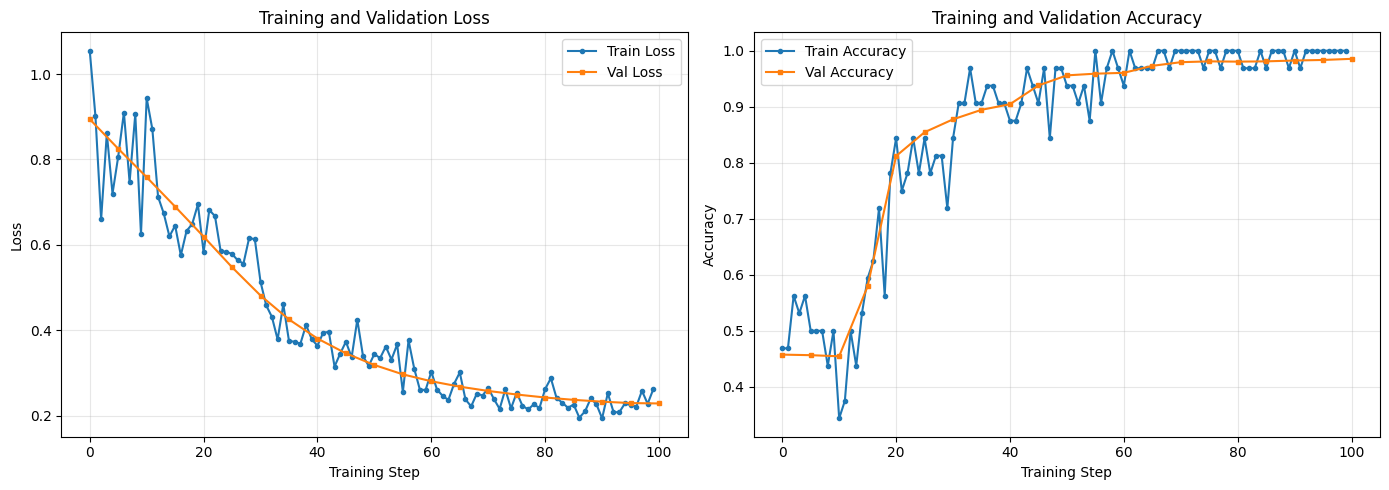

In [7]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train Loss', marker='o', markersize=3)
if history['val_loss']:
    ax1.plot([i * 5 for i in range(len(history['val_loss']))], history['val_loss'], 
             label='Val Loss', marker='s', markersize=3)
ax1.set_xlabel('Training Step')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o', markersize=3)
if history['val_acc']:
    ax2.plot([i * 5 for i in range(len(history['val_acc']))], history['val_acc'], 
             label='Val Accuracy', marker='s', markersize=3)
ax2.set_xlabel('Training Step')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Confusion Matrix:
[[ 952   18]
 [  62 3968]]

Classification Report:
              precision    recall  f1-score   support

      normal       0.94      0.98      0.96       970
      attack       1.00      0.98      0.99      4030

    accuracy                           0.98      5000
   macro avg       0.97      0.98      0.97      5000
weighted avg       0.98      0.98      0.98      5000



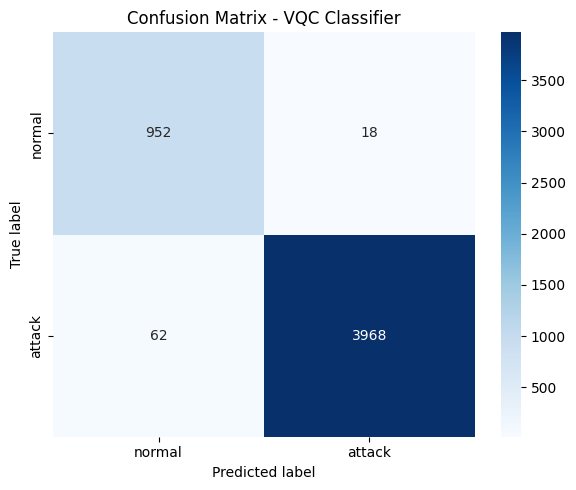

In [8]:
# Get predictions and compute confusion matrix
y_pred_raw = vqc.predict(X_test_subset, best_params)

# Convert to regular numpy array to avoid PennyLane ArrayBox issues
y_pred = np.array(y_pred_raw, dtype=int)
y_test_subset_int = np.array(y_test_subset, dtype=int)

cm_vqc = confusion_matrix(y_test_subset_int, y_pred)

print("Confusion Matrix:")
print(cm_vqc)
print("\nClassification Report:")
print(classification_report(y_test_subset_int, y_pred, target_names=["normal", "attack"]))

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_vqc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["normal", "attack"],
    yticklabels=["normal", "attack"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - VQC Classifier")
plt.tight_layout()
plt.show()